# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('../data/source1/creditcard.csv')
num_rows, num_cols = data.shape

In [3]:
print(f"The dataset has {num_rows:,} rows and {num_cols} columns.")

The dataset has 284,807 rows and 31 columns.


In [4]:
null_counts = data.isnull().sum()

if null_counts.sum() == 0:
    print("No missing values found in any of the 31 columns. Yay!")
else:
    print("We have null values!!")
    print(null_counts[null_counts > 0])


No missing values found in any of the 31 columns. Yay!


It is given that the `Class` column is the response variable (label).

In [5]:
class_counts = data['Class'].value_counts()
class_counts.to_frame(name='Counts').head()

,Counts
Class,
0,284315
1,492


In [6]:
for name, count in zip(class_counts.index, class_counts):
    print(f"Of {num_rows:,} transactions, {count:,} are {'fraudulent' if name else 'genuine'}.")

print(f"i.e. {class_counts[1]/num_rows:.2%} of all transactions are fraudulent.")


Of 284,807 transactions, 284,315 are genuine.
Of 284,807 transactions, 492 are fraudulent.
i.e. 0.17% of all transactions are fraudulent.


In [7]:
print("Column names: ", end="")

for i, col_name in enumerate(data.columns):
    if i == num_cols - 1:
        print(col_name, end=". ")
    elif i == num_cols - 2:
        print(col_name, end=", and ")
    else:
        print(col_name, end=", ")

Column names: Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, Amount, and Class. 

Which of these features correlate to fraudulent activity?

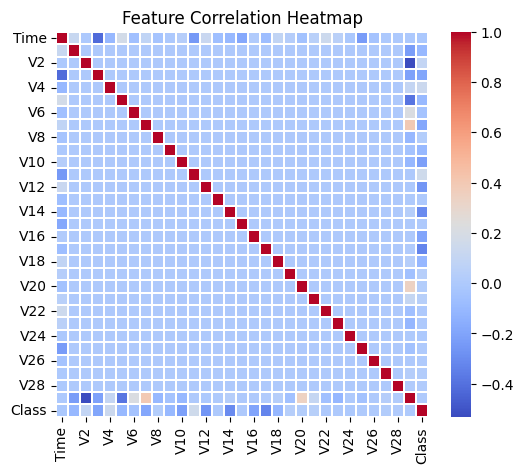

In [8]:
corr = data.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.1)
plt.title('Feature Correlation Heatmap')
plt.show()

In [9]:
abs_class_corr = corr.loc[corr['Class'].abs().sort_values(ascending=False).drop('Class').index, ['Class']].copy()
abs_class_corr.columns = ['Correlation']
abs_class_corr = abs_class_corr.reset_index().rename(columns={'index': 'Feature'})
abs_class_corr.index = abs_class_corr.index + 1
abs_class_corr.head(10)

,Feature,Correlation
1,V17,-0.326481
2,V14,-0.302544
3,V12,-0.260593
4,V10,-0.216883
5,V16,-0.196539
6,V3,-0.192961
7,V7,-0.187257
8,V11,0.154876
9,V4,0.133447
10,V18,-0.111485


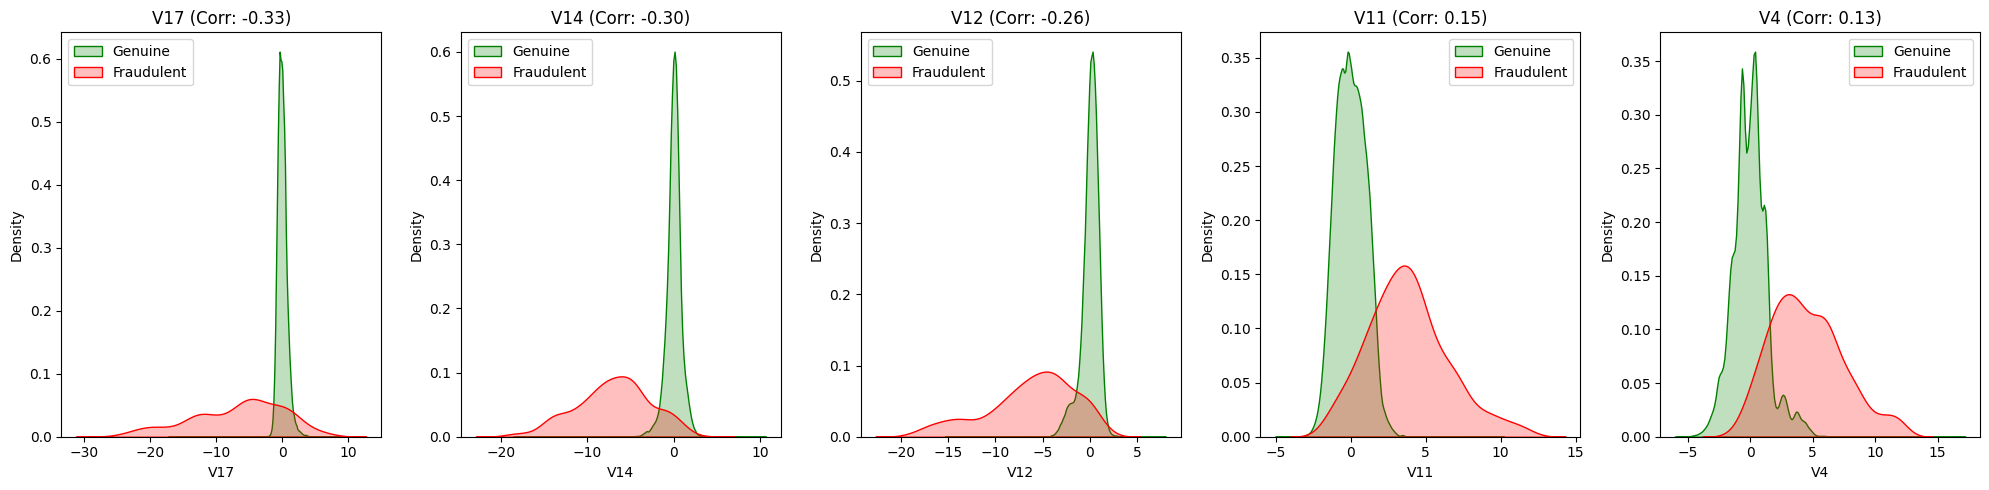

In [10]:
top_features = ['V17', 'V14', 'V12', 'V11', 'V4']

fig, axes = plt.subplots(1, len(top_features), figsize=(20, 5))

for i, feature in enumerate(top_features):
    sns.kdeplot(data=data[data['Class'] == 0], x=feature, ax=axes[i], label='Genuine', fill=True, color='green')
    sns.kdeplot(data=data[data['Class'] == 1], x=feature, ax=axes[i], label='Fraudulent', fill=True, color='red')
    axes[i].set_title(f'{feature} (Corr: {corr["Class"][feature]:.2f})')
    axes[i].legend()

plt.tight_layout()
plt.show()

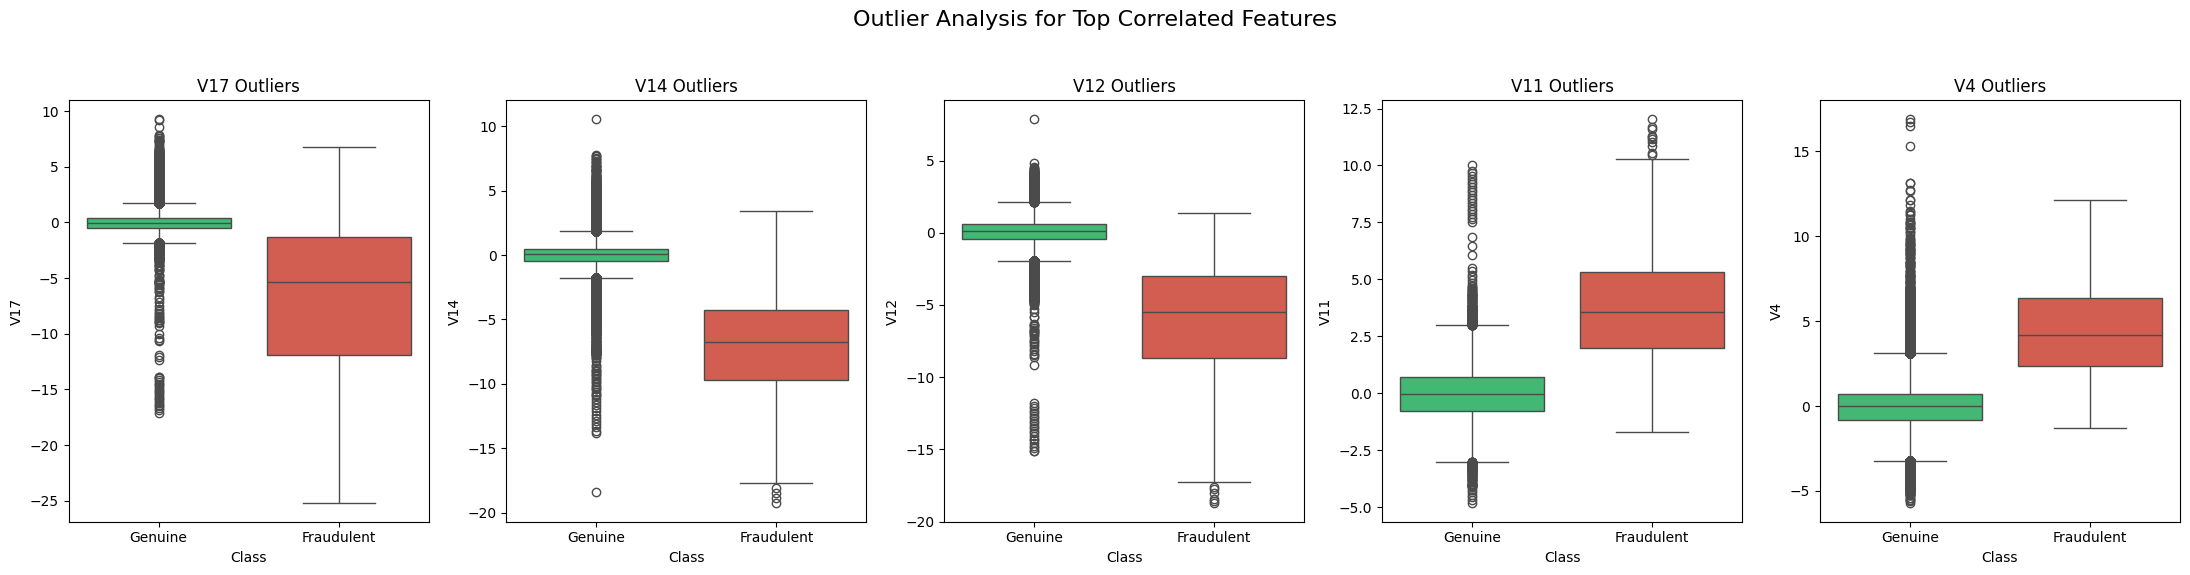

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for i, feature in enumerate(top_features):
    sns.boxplot(x='Class', y=feature, data=data, palette=['#2ecc71', '#e74c3c'], ax=axes[i], hue='Class', legend=False)
    axes[i].set_title(f'{feature} Outliers', fontsize=12)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Genuine', 'Fraudulent'])

plt.suptitle('Outlier Analysis for Top Correlated Features', fontsize=16)
plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

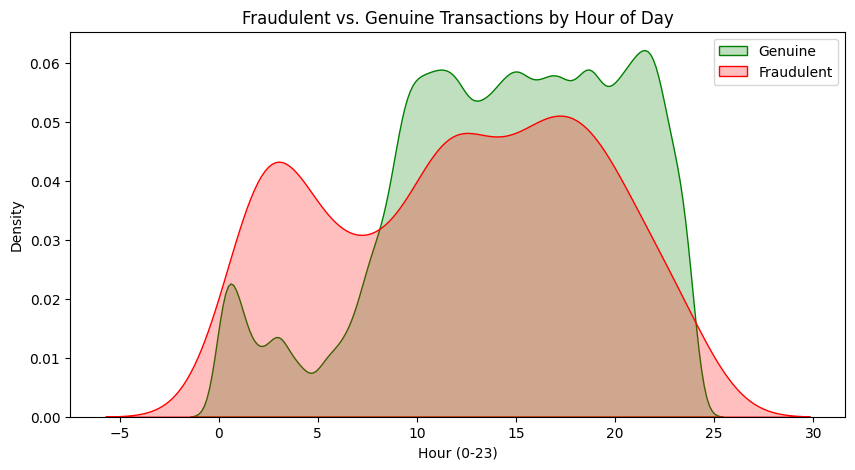

In [12]:
data['Hour'] = (data['Time'] / 3600) % 24

plt.figure(figsize=(10, 5))

sns.kdeplot(x=data[data['Class'] == 0]['Hour'], label='Genuine', fill=True, color='green')
sns.kdeplot(x=data[data['Class'] == 1]['Hour'], label='Fraudulent', fill=True, color='red')

plt.title('Fraudulent vs. Genuine Transactions by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.legend()
plt.show()

In [13]:
desc_amt = data['Amount'].describe().to_frame()

formats = {
    'count': "{:,.0f}",
    'mean': "${:,.2f}",
    'std': "{:,.2f}",
    'min': "${:,.2f}",
    '25%': "${:,.2f}",
    '50%': "${:,.2f}",
    '75%': "${:,.2f}",
    'max': "${:,.2f}"
}

styled_df = pd.DataFrame(
    { 'Amount': [formats[str(idx)].format(val) for idx, val in desc_amt['Amount'].items()] },
    index=desc_amt.index
)

styled_df

,Amount
count,"284,807"
mean,$88.35
std,250.12
min,$0.00
25%,$5.60
50%,$22.00
75%,$77.16
max,"$25,691.16"


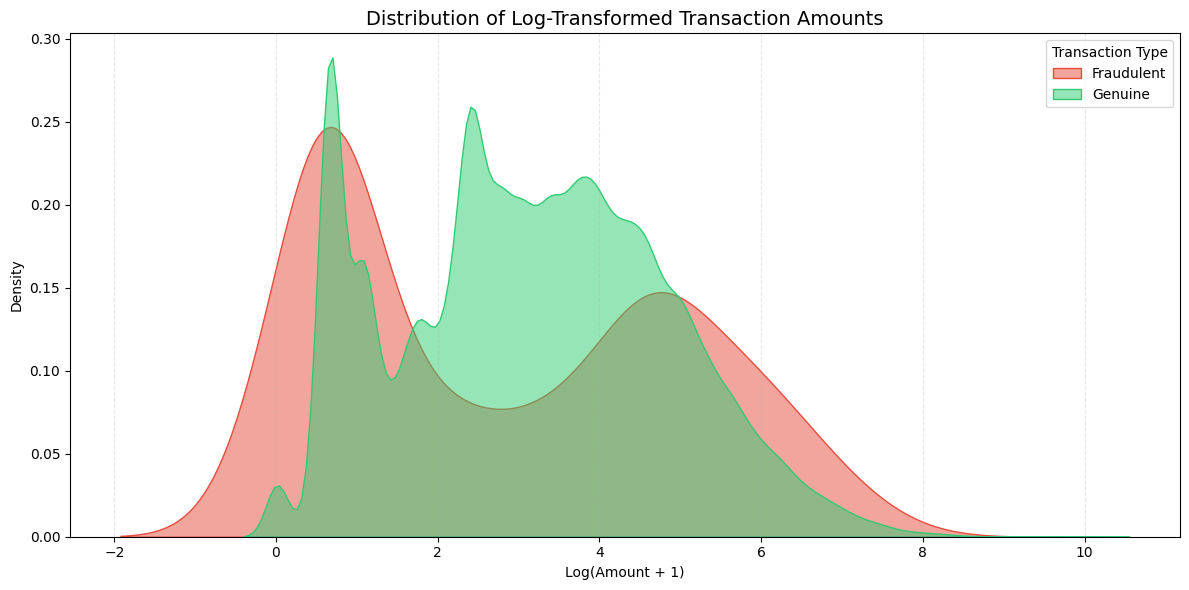

In [14]:
data['Log_Amount'] = np.log1p(data['Amount'])

plt.figure(figsize=(12, 6))

ax = sns.kdeplot(
    data=data, 
    x='Log_Amount', 
    hue='Class', 
    fill=True, 
    common_norm=False, 
    palette=['#2ecc71', '#e74c3c'], 
    alpha=0.5
)

plt.legend(title='Transaction Type', labels=['Fraudulent', 'Genuine'])

plt.title('Distribution of Log-Transformed Transaction Amounts', fontsize=14)
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Density')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Summary of Insights:

* Data Health: Confirmed 0 missing values and no immediate data entry errors.
* Class Imbalance: Extreme skew (0.17% fraud) means standard accuracy is a useless metric; we shall require Precision-Recall/AUC-ROC and likely SMOTE/oversampling.
* Feature Relationships: Features such as V17 and V14 show distinct separations between classes, making them strong candidates for model training.
* Amount Distribution: The Amount is heavily skewed and contains $0.00 "ping" transactions, necessitating log transformation or robust scaling to normalise the data.
* Outliers: Boxplots highlight significant outliers in highly correlated features, suggesting that outlier removal (e.g. using Interquartile Range) might improve how the model generalises to new data.